<div align="center">
<h1>Scatterplots e histogramas</h1>
</div>
Los scatterplots y los histogramas son herramientas clave para visualizar relaciones entre variables y comprender la distribución de datos en el análisis de datos.

## Scatterplots
Un scatterplot o gráfico de dispersión es una representación gráfica que se emplea para mostrar la relación entre dos variables numéricas. Cada uno de los puntos que aparece en el gráfico representa una observación en el conjunto de datos con coordenadas que corresponden a los valores de las variables que hemos elegido representar. Permite observar patrones, correlaciones, tendencias e incluso posibles anomalías entre las dos variables.

Los scatterplots se utilizan en el análisis de datos, por ejemplo, para identificar relaciones y correlaciones entre variables, como la relación entre el gasto en publicidad y las ventas de un producto.

Ejemplo de creación de un scatterplot
Para cada tipo de gráfico, lo primero de todo es incluir esto en nuestros códigos:

In [1]:
import pandas as pd
from plotnine import*
from plotnine.data import *

In [2]:
mpg=mpg

Primero creamos un scatterplot con la variable X displ (cilindrada del motor, en litros) y Y hwy (millas recorridas por galón de gasolina). Añadimos theme_bw() para obtener un marco alrededor del gráfico

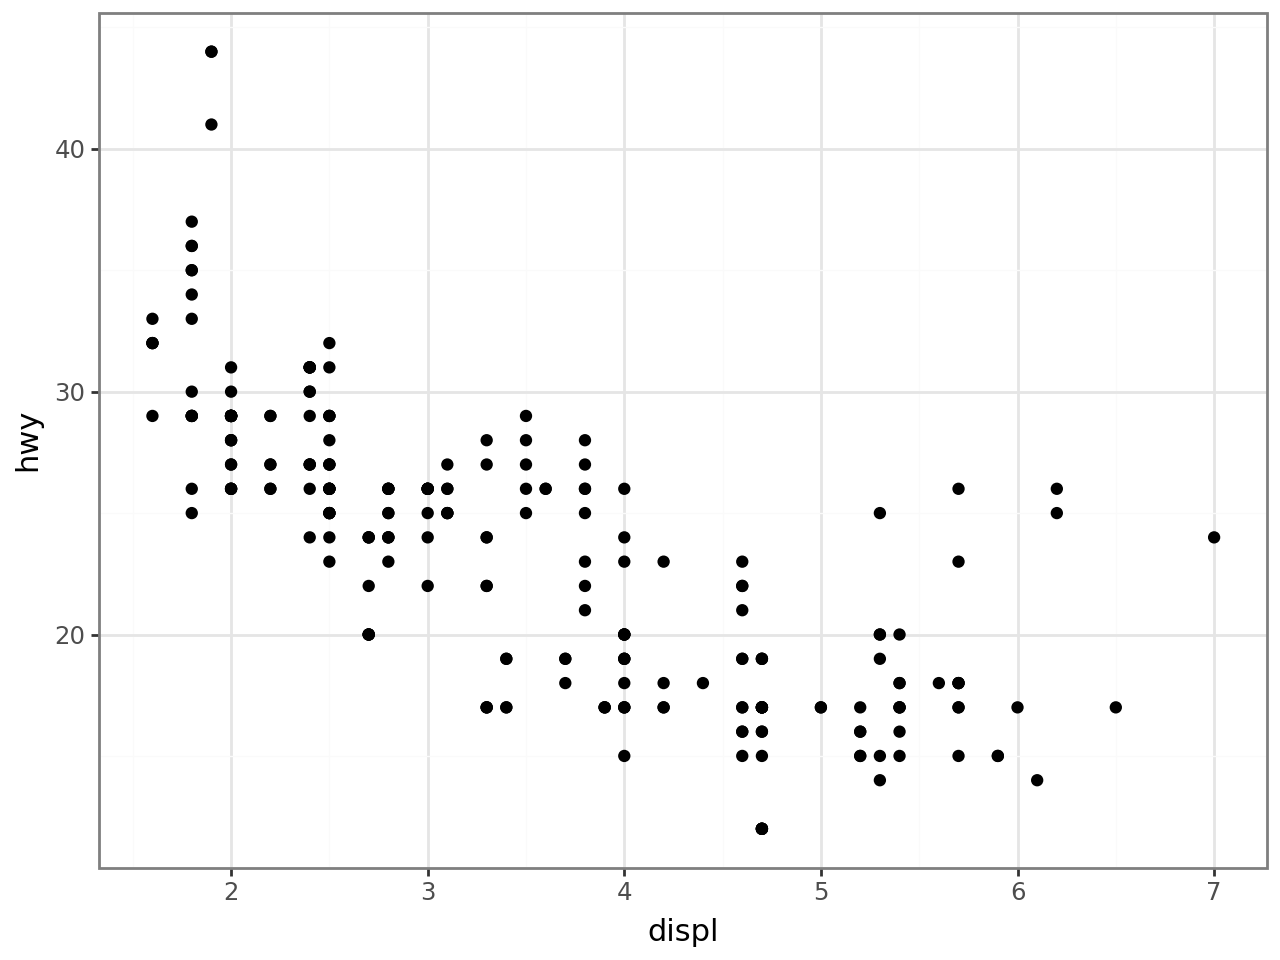

In [4]:
ggplot(aes("displ","hwy"),mpg)+geom_point()+theme_bw()

Ahora vamos a crear una tercera dimensión, lo que significa agregar una nueva variable. En este caso, hemos añadido el tipo de vehículo, que señalamos con colores:

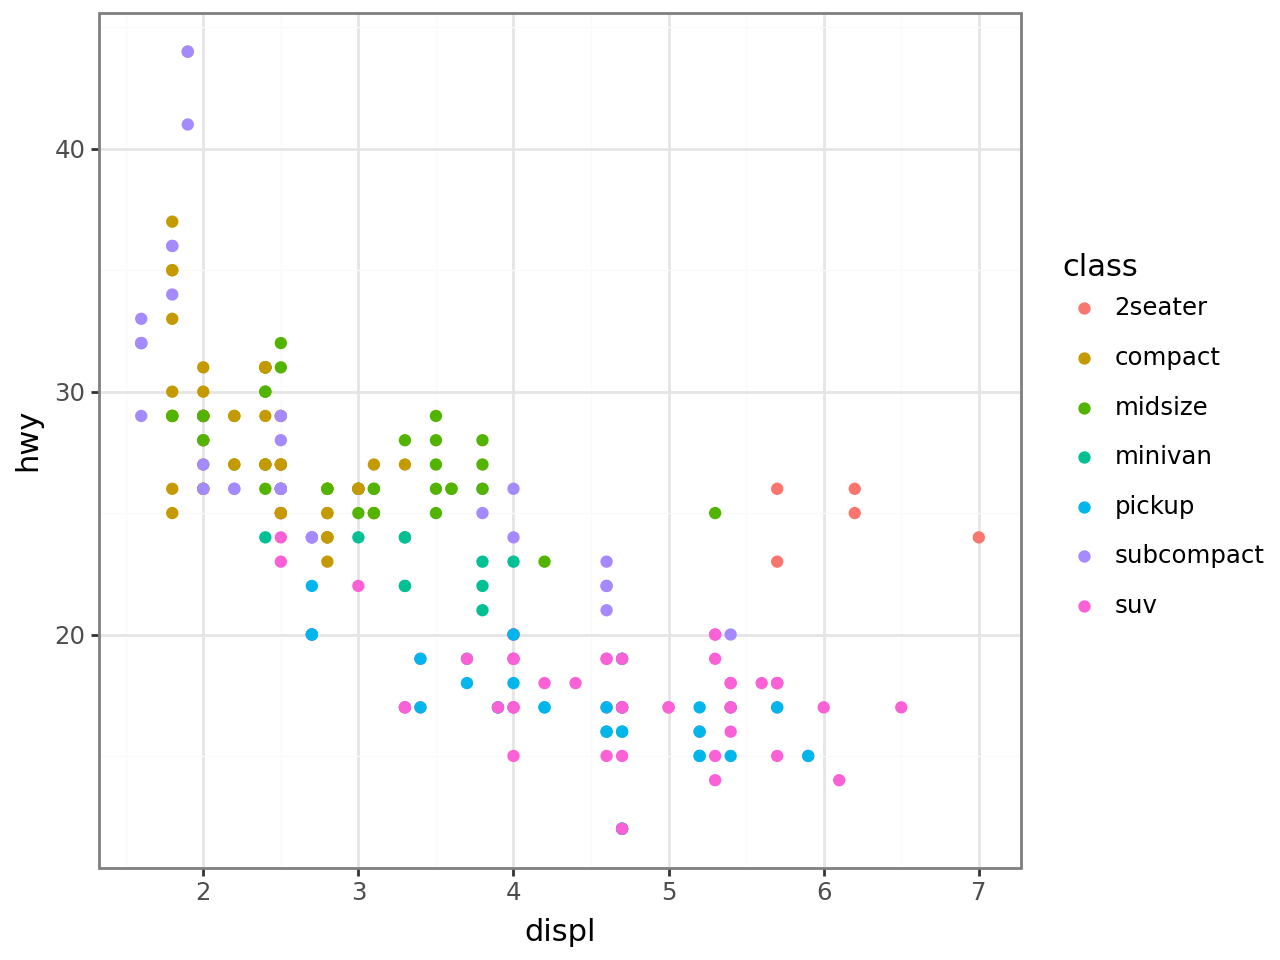

In [5]:
ggplot(aes("displ","hwy", color ="class"),mpg)+geom_point()+theme_bw()

También podemos agregar diferentes formas a los puntos, para facilitar la visualización:

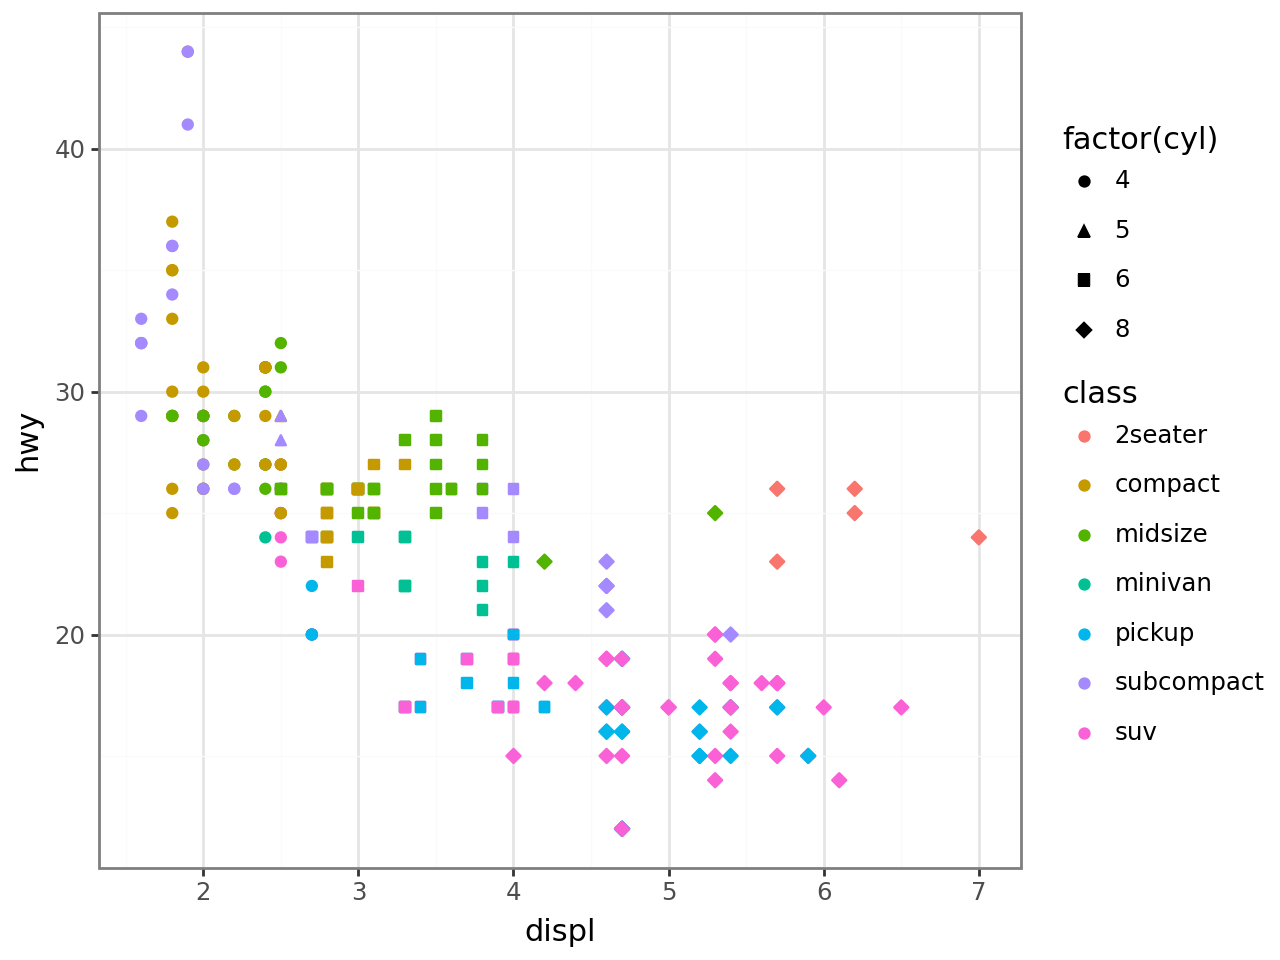

In [8]:
ggplot(aes("displ","hwy", color ="class"),mpg)+geom_point(aes(shape="factor(cyl)"))+theme_bw()

Creamos una línea de regresión en color azul:

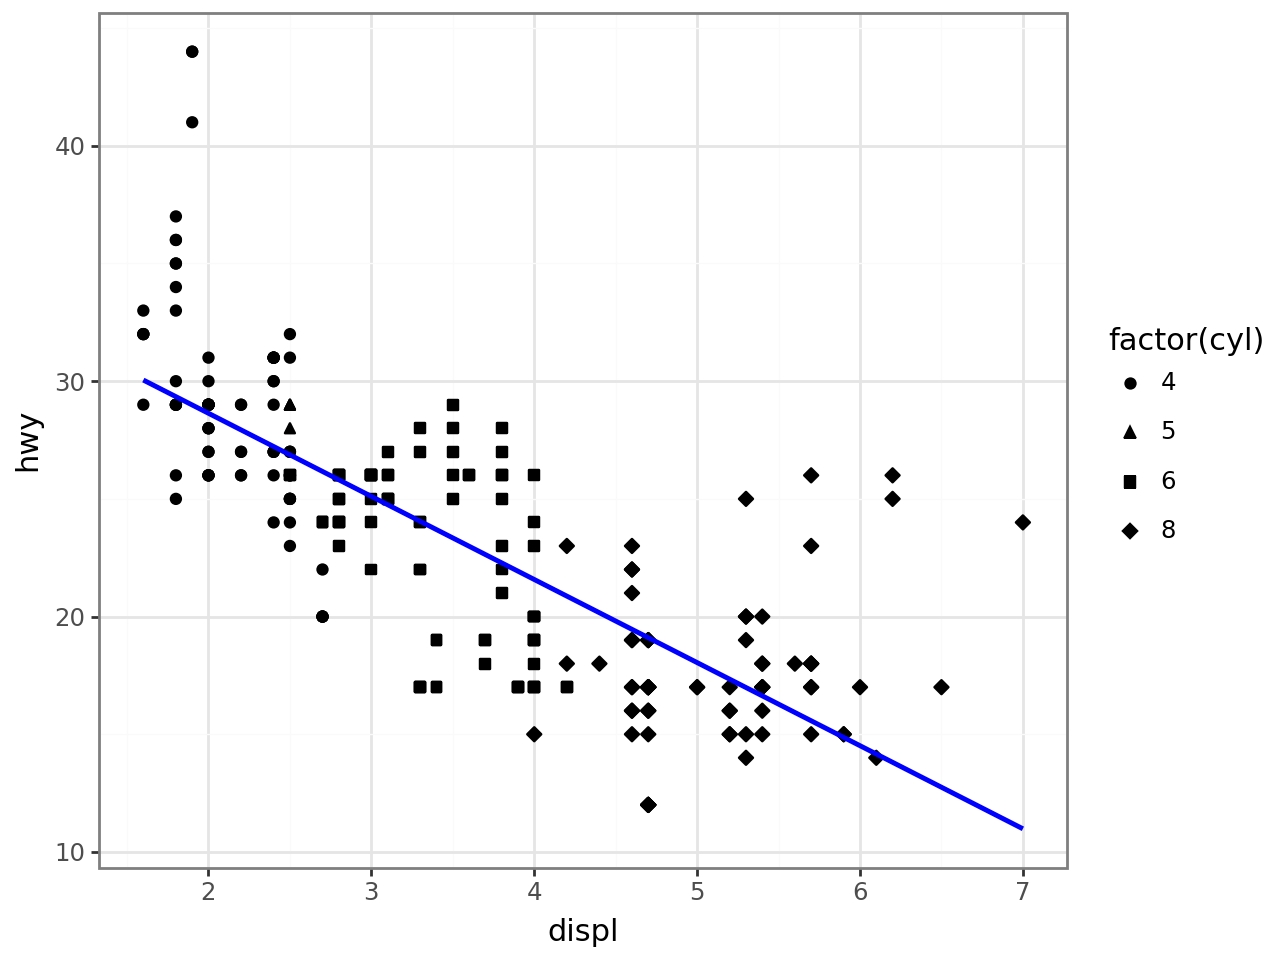

In [9]:
ggplot(aes("displ","hwy"),mpg)+geom_point(aes(shape="factor(cyl)"))+geom_smooth(method="lm",se=False, color="blue")+theme_bw()

Una regresión lineal muestra la línea de tendencia del conjunto de resultados del diagrama de dispersión. Es una línea recta que representa mejor los datos en el gráfico de dispersión y minimiza la distancia entre las puntuaciones reales y las puntuaciones previstas.

También podemos crear varias líneas de regresión, en función de cuántos valores hayamos añadido a la variable de color que hemos creado antes:

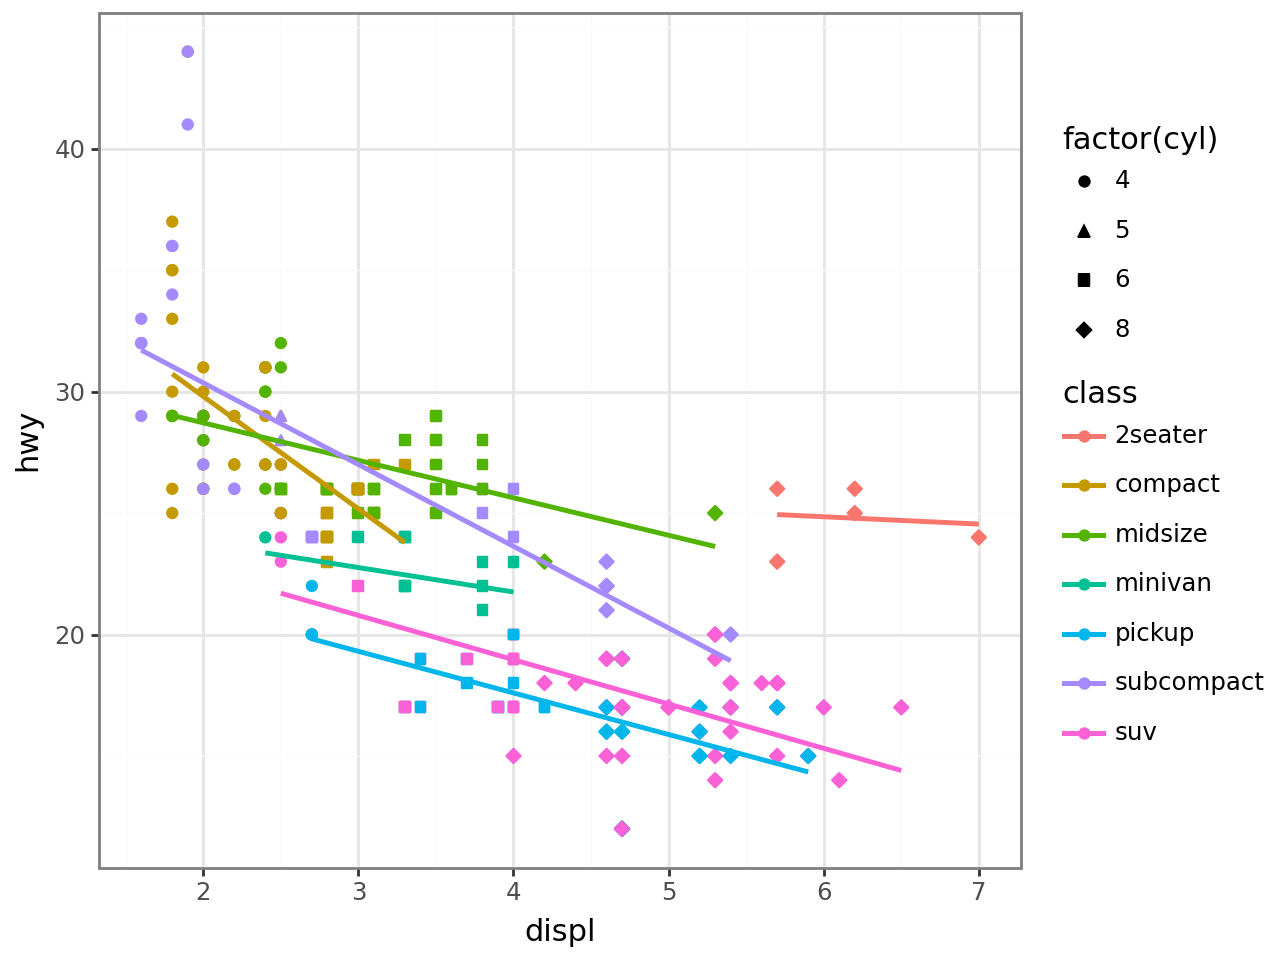

In [10]:
ggplot(aes("displ","hwy", color ="class"),mpg)+geom_point(aes(shape="factor(cyl)"))+geom_smooth(method="lm",se=False)+theme_bw()

Podemos editar el scatterplot para que sea más sencillo de leer o recalque cierta información. Por ejemplo, podemos realizar:

Mapeos estéticos, en este caso por número de cilindros en el motor. 

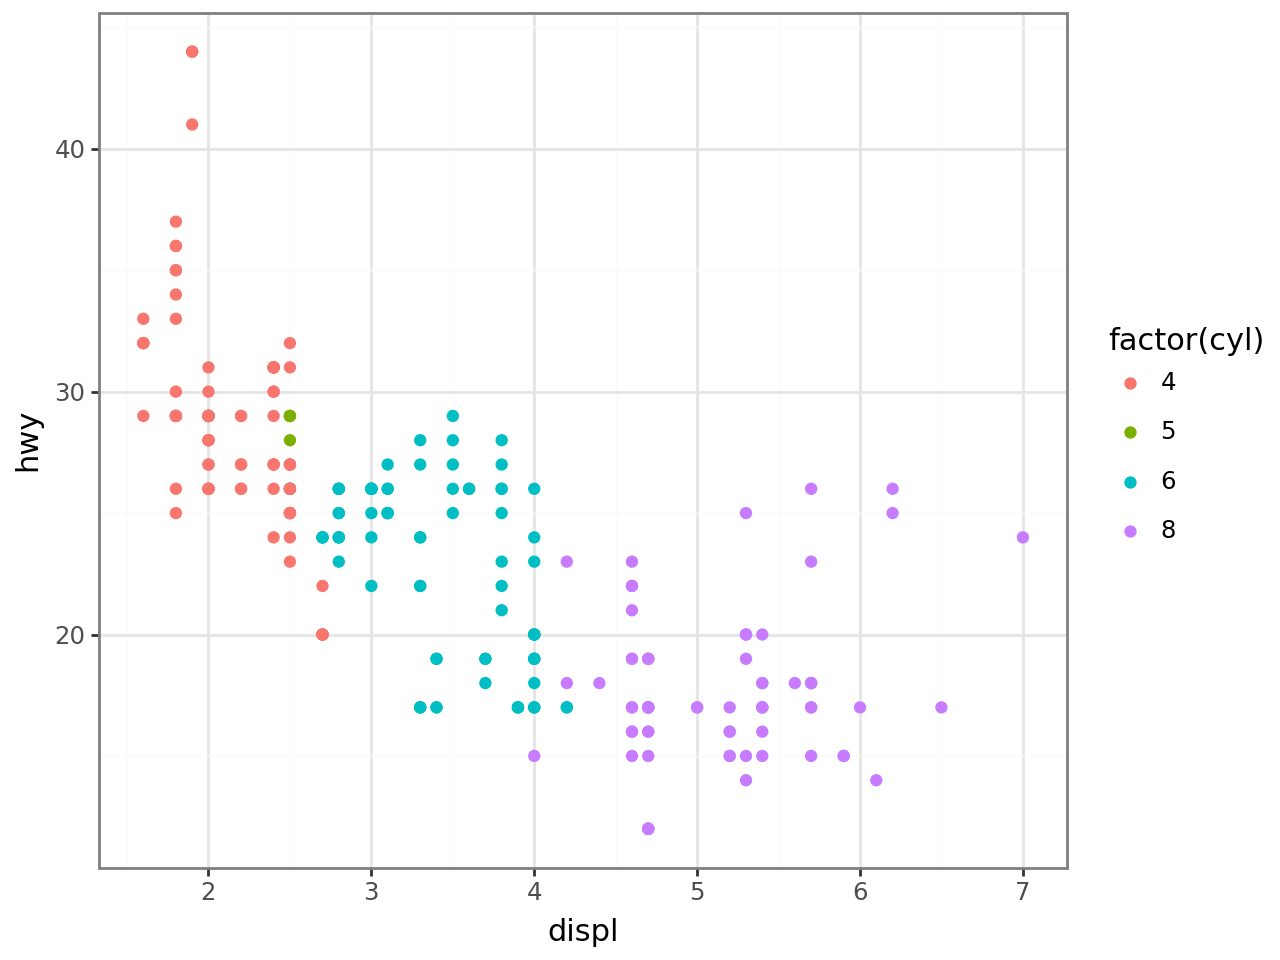

In [11]:
ggplot(aes("displ","hwy"),mpg)+geom_point(aes(color='factor(cyl)'))+theme_bw()

Modificar la escala de colores: asignamos azul a valores bajos y rojo a valores altos. 

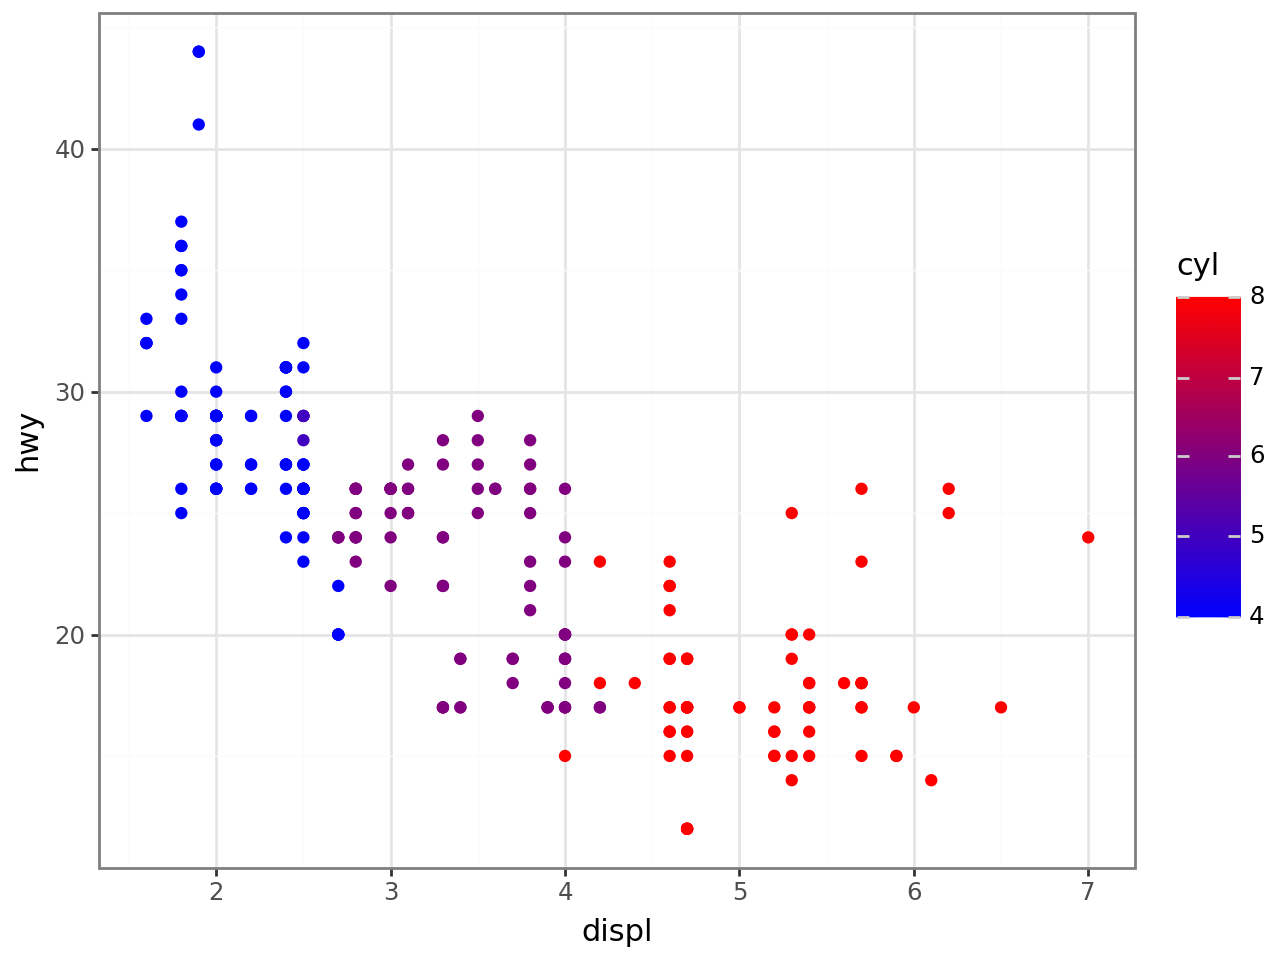

In [12]:
ggplot(aes("displ","hwy"),mpg)+geom_point(aes(color='cyl'))+ scale_color_gradient(low='blue', high='red')+theme_bw()

Modificar el tamaño: a mayor número de millas recorridas por galón, mayor es el tamaño del punto.

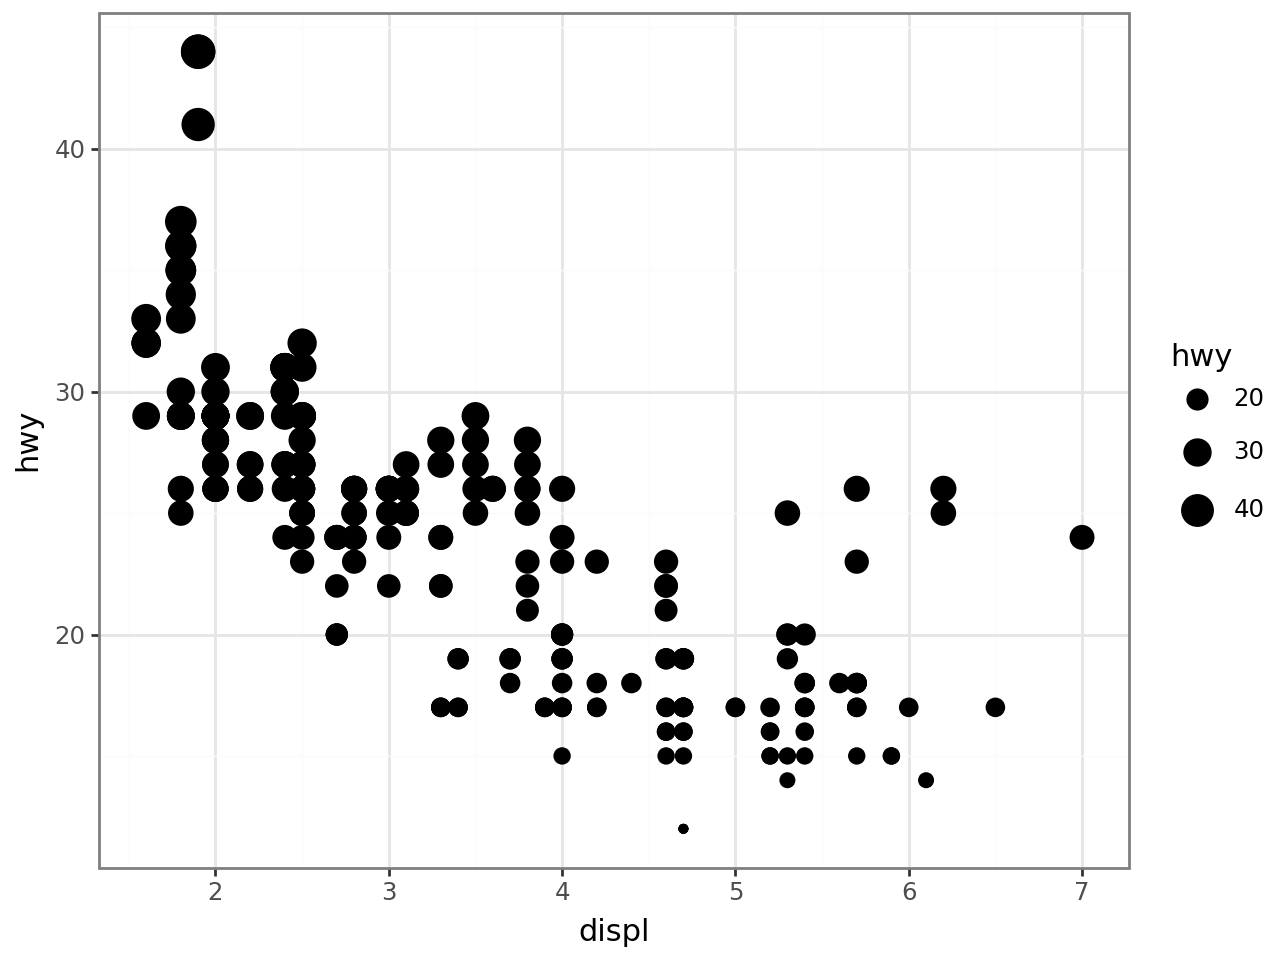

In [13]:
ggplot(aes("displ","hwy"),mpg)+geom_point(aes(size='hwy'))+theme_bw()

Añadimos nombres a los ejes: permite identificar las variables de forma más sencilla.

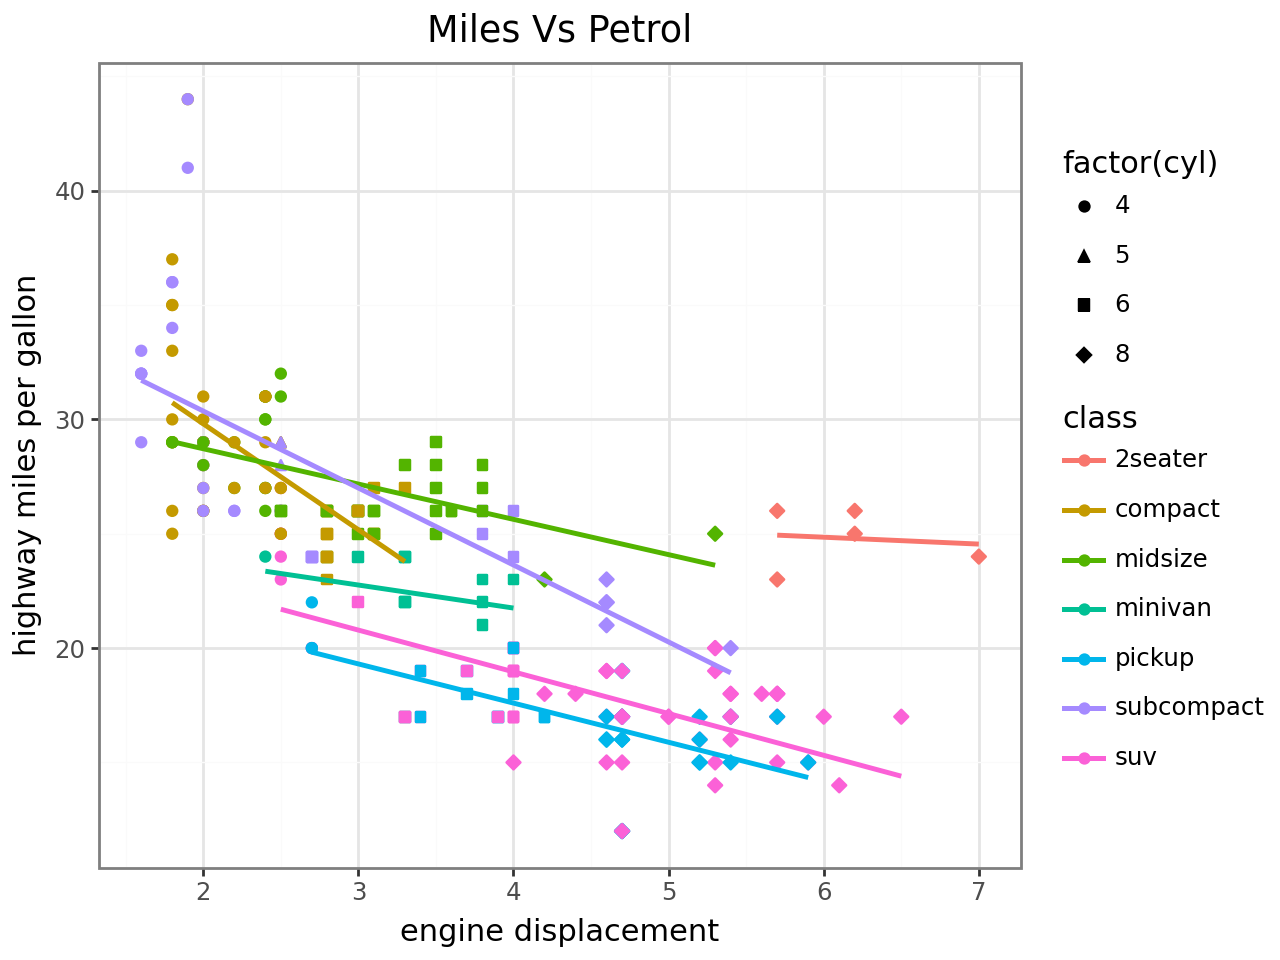

In [14]:
ggplot(aes("displ","hwy", color ="class"), mpg) + \
geom_point(aes(shape="factor(cyl)")) + \
geom_smooth(method="lm", se=False) + \
theme_bw() + \
ggtitle("Miles Vs Petrol") + \
xlab("engine displacement") + \
ylab("highway miles per gallon")

## Histogramas
Un histograma es una representación gráfica de la distribución de un conjunto de datos numéricos. Se emplea para mostrar frecuencias o densidades dentro de intervalos y es muy útil para representar distribuciones de datos, detectar patrones, identificar outliers y comparar distribuciones.

Los histogramas se utilizan, por ejemplo, para visualizar la frecuencia de diferentes puntuaciones en una encuesta.

c:\Users\Easy Data\Dropbox\PC\Documents\Lenguajes para analisis de datos II\.venv-1\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 11'. Pick better value with 'binwidth'.


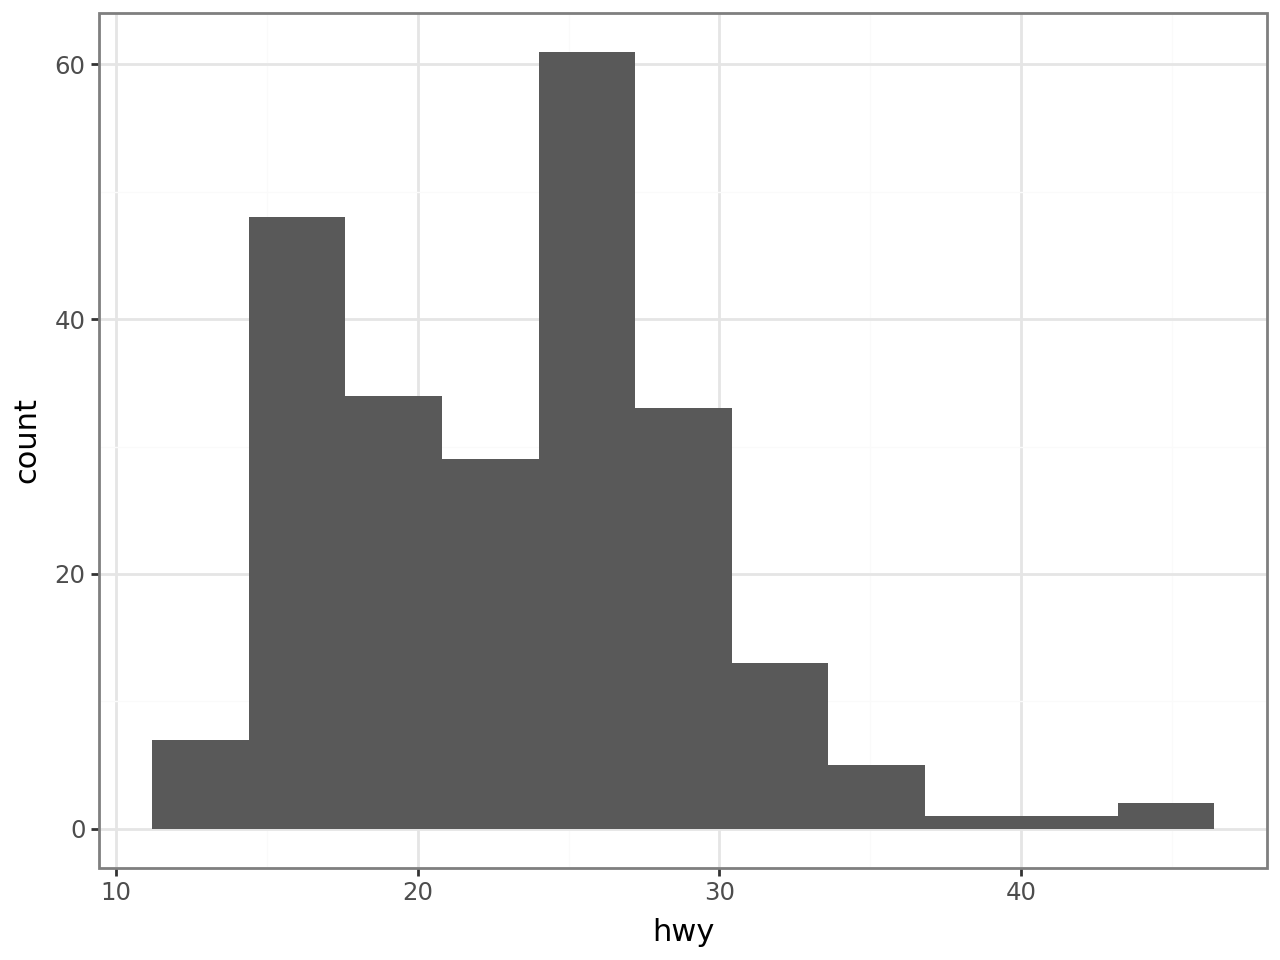

In [15]:
ggplot(aes("hwy"),mpg)+geom_histogram()+theme_bw()

Ahora creamos una segunda dimensión, agregando fill. En este caso, es el tipo de vehículo, class.

c:\Users\Easy Data\Dropbox\PC\Documents\Lenguajes para analisis de datos II\.venv-1\Lib\site-packages\plotnine\stats\stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 11'. Pick better value with 'binwidth'.


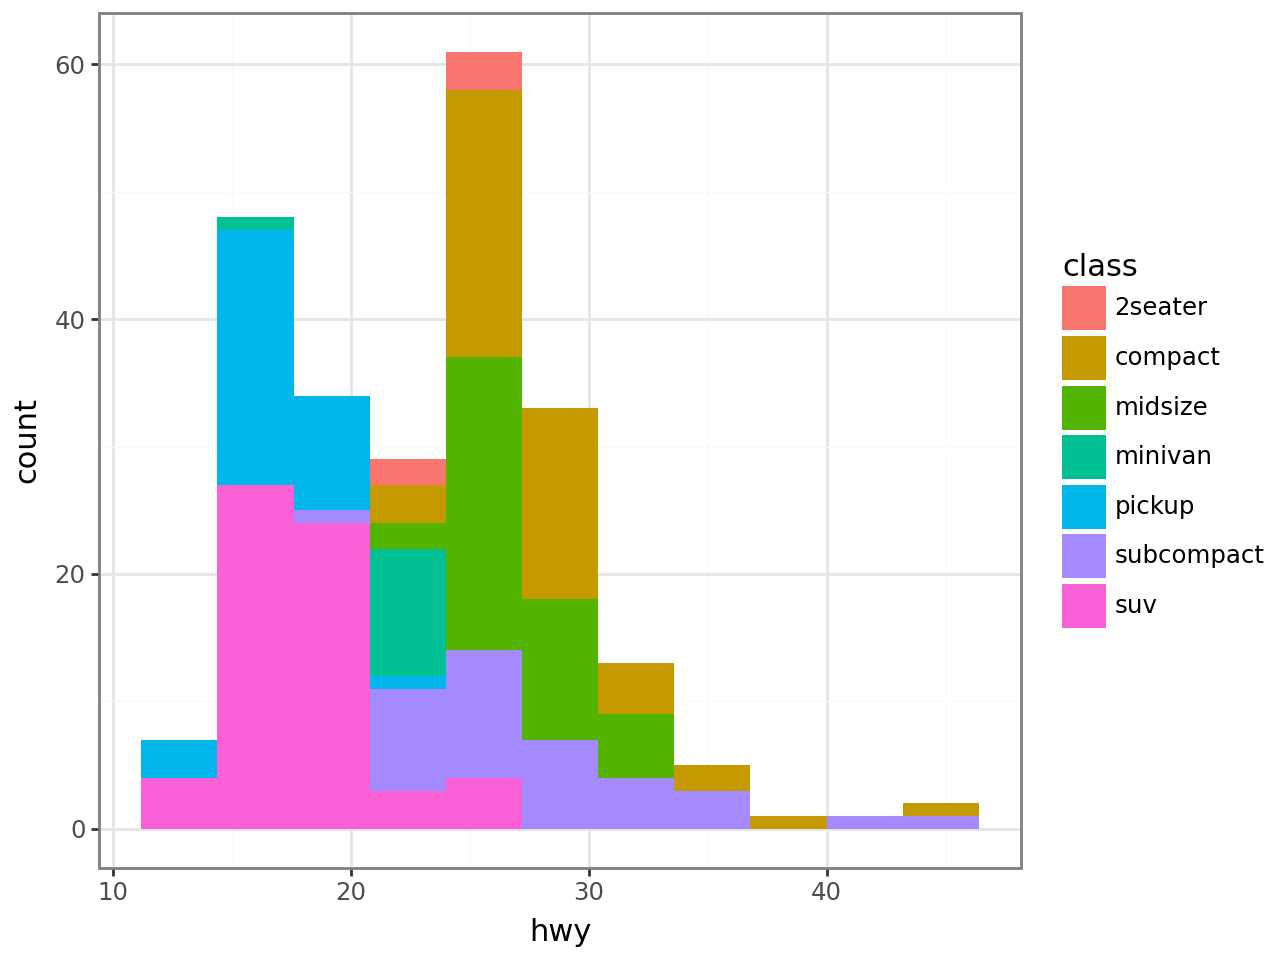

In [16]:
ggplot(aes("hwy",fill="class"),mpg)+geom_histogram()+theme_bw()

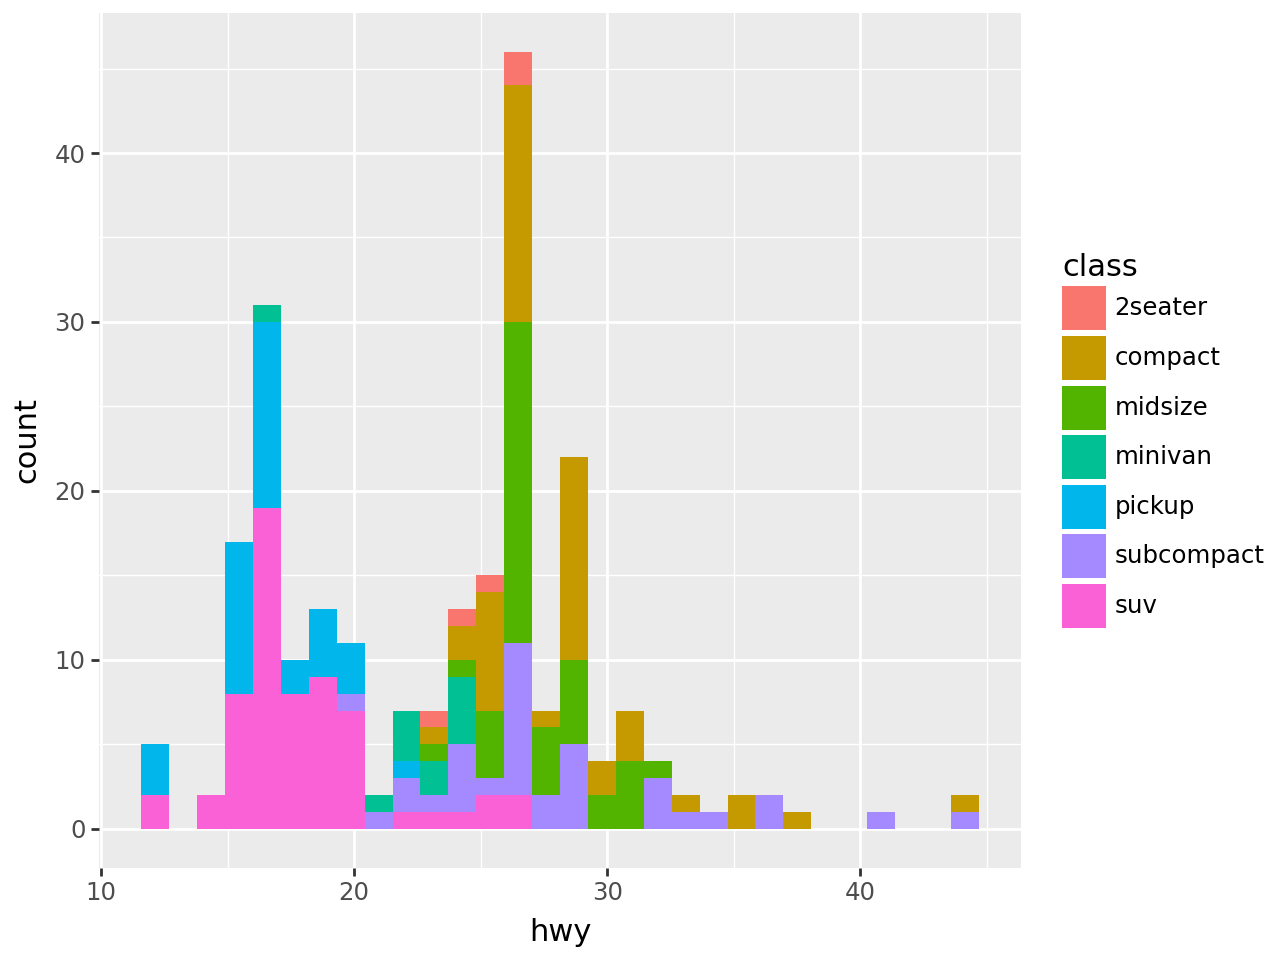

In [18]:
ggplot(aes("hwy",fill="class"),mpg)+geom_histogram(bins=30)

Vamos a ajustar los colores con Alpha, que define la densidad del color.

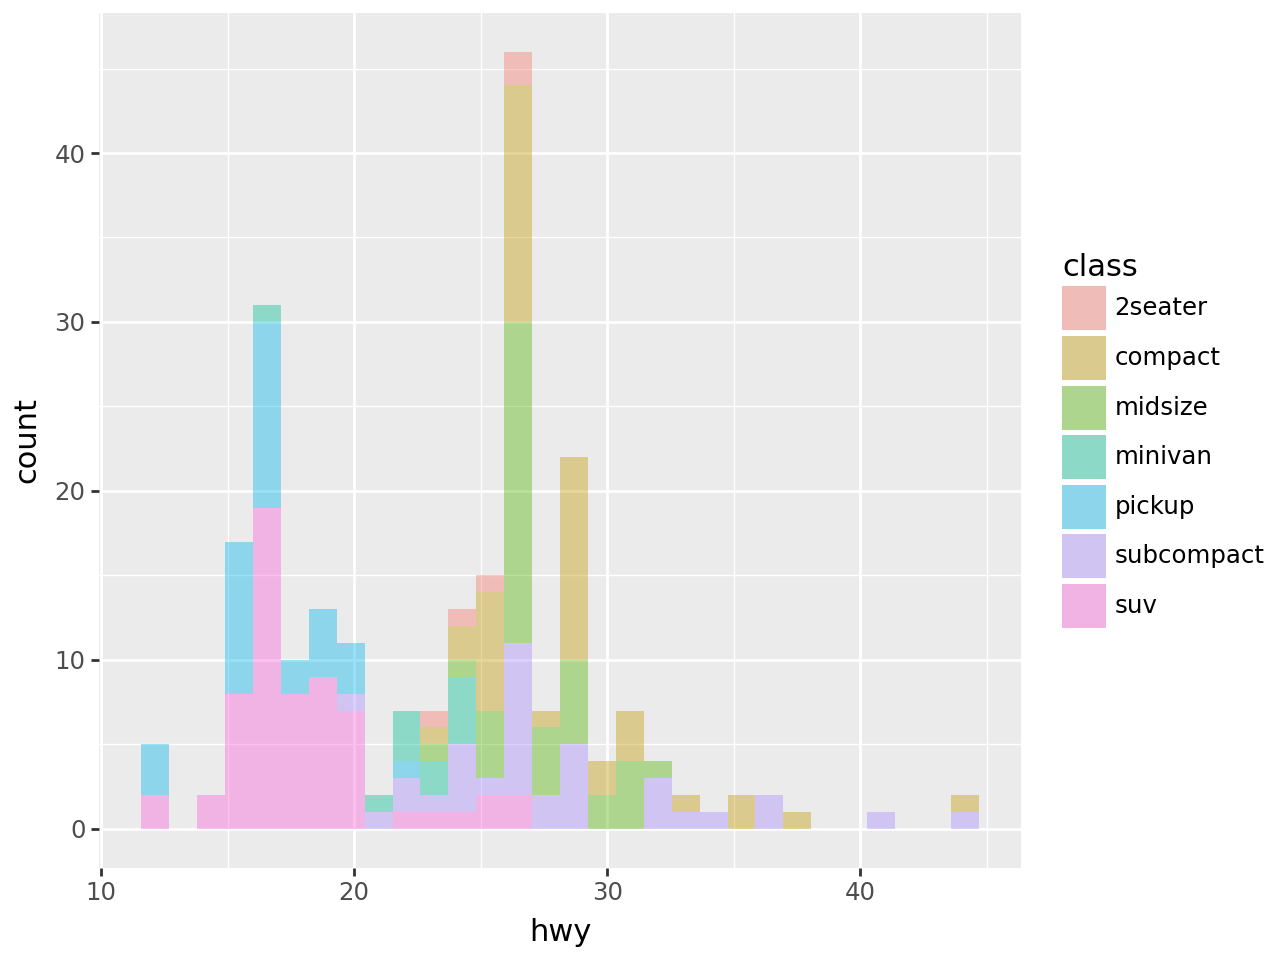

In [19]:
ggplot(aes("hwy",fill="class"),mpg)+geom_histogram(bins=30,alpha=0.4)

Para incluir una leyenda que explique los datos representados, emplearemos legend

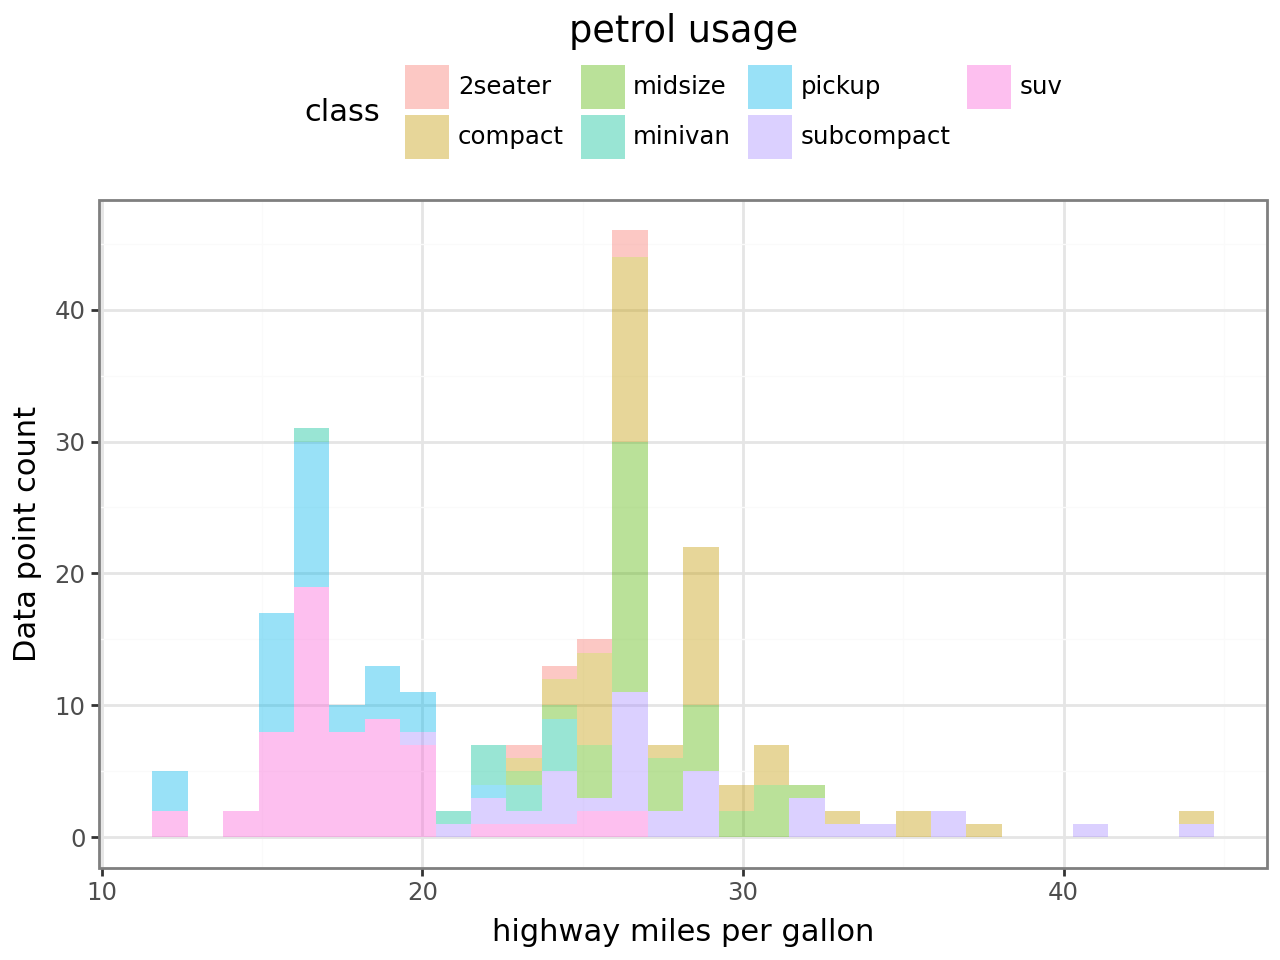

In [22]:
ggplot(aes("hwy",fill="class"),mpg)+geom_histogram(bins=30,alpha=0.4) + \
theme_bw()+ggtitle("petrol usage") + \
ylab("Data point count")+xlab("highway miles per gallon") + \
theme(legend_position = "top")

Si queremos visualizar la distribución de una variable individual, podemos emplear facet_wrap para separar el histograma por variables.

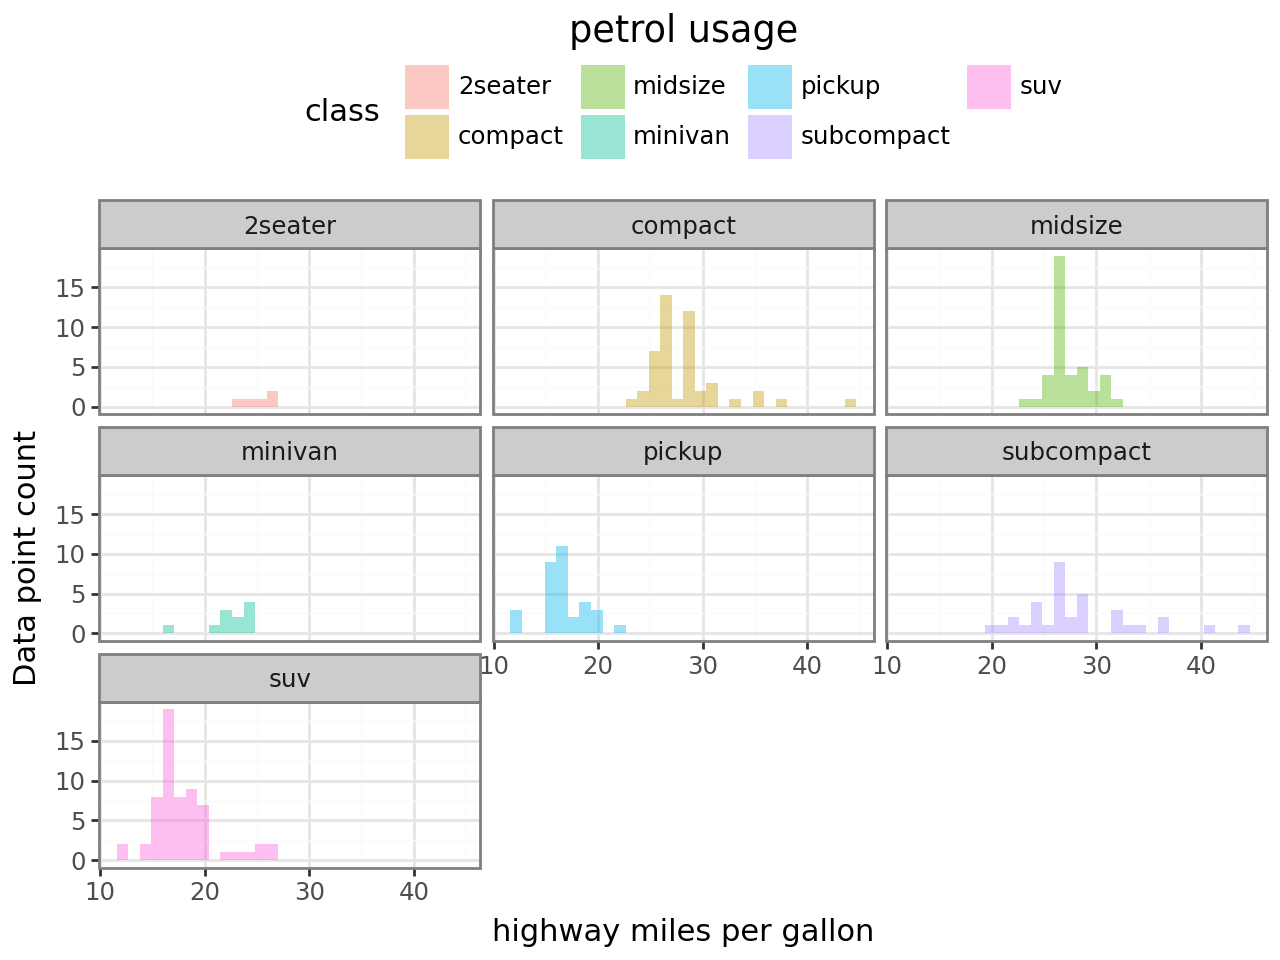

In [23]:
ggplot(aes("hwy",fill="class"),mpg)+geom_histogram(bins=30,alpha=0.4)+ theme_bw()+ggtitle("petrol usage") +\
ylab("Data point count")+xlab("highway miles per gallon")+\
theme(legend_position = "top", plot_title=element_text(hjust=0.5))+facet_wrap("class")